# DNU EDA — Comparación de clasificadores

Natalia Debandi

Análisis exploratorio del dataset DNU 70/2017 extendido con las predicciones de seis clasificadores de discurso de odio.

| Clasificador | Modelo | Etiqueta positiva |
|---|---|---|
| **HATEFUL** | piuba-bigdata/beto-contextualized-hate-speech | OR de todas las categorías excepto `CALLS` |
| **RACISM** | piuba-bigdata/beto-contextualized-hate-speech | categoría `RACISM` |
| **GPT** | GPT-4o zero-shot (Batch API) | `gpt_is_xenophobic = True` |
| **Cardiff** | XLM-RoBERTa (CardiffNLP) | `HATE` |
| **BNE** | RoBERTa (BNE, hate+offensive) | `HATE` o `OFFENSIVE` |
| **BETO** | BETO fine-tuned hate speech v2 | `LABEL_1` |
| **pysentimiento** | RoBERTuito (pysentimiento) | `pysentimiento_hate__binary_pred = 1` |

> **Nota:** Se excluyen del análisis los tweets (y sus RTs) que contienen las palabras *Chile* o *Perú*, ya que refieren mayoritariamente a migración de esos países y distorsionan el análisis de xenofobia en contexto DNU.

## 1. Imports y configuración

In [1]:
import re
import html as htmllib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, HTML

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

FILE_V2     = 'data/DNU_clasificadores_v2.csv'
FILE_BASE   = 'data/tweets_dnu_clasificados.csv'
FILE_PYSENT = 'data/DNU_pysentiment_full.csv'

CLASIF = ['HATEFUL', 'RACISM', 'GPT', 'Cardiff', 'BNE', 'BETO', 'pysentimiento']
LABEL_COLS = ['WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL', 'CALLS']

COLORS = {
    'HATEFUL':       '#2c3e50',
    'RACISM':        '#c0392b',
    'GPT':           '#2980b9',
    'Cardiff':       '#27ae60',
    'BNE':           '#e74c3c',
    'BETO':          '#8e44ad',
    'pysentimiento': '#e67e22',
}

## 2. Carga de datos

In [2]:
# Dataset principal con predicciones de todos los modelos
df = pd.read_csv(FILE_V2, low_memory=False)
df['fecha']     = pd.to_datetime(df['fecha'], utc=True)
df['fecha_dia'] = pd.to_datetime(df['fecha_dia'])

# Columnas adicionales del dataset base (etiquetas individuales + reply info)
extra = pd.read_csv(
    FILE_BASE,
    usecols=['id', 'in_reply_to_status_id', 'n_labels'] + LABEL_COLS,
    low_memory=False,
)
df = df.merge(extra, on='id', how='left')

# RACISM: normalizar a int (viene como bool True/False del base)
df['RACISM'] = pd.to_numeric(df['RACISM'], errors='coerce').fillna(0).astype(int)

# ── Reemplazar pysentimiento con clasificación completa ───────────────────────
pysent_full = pd.read_csv(
    FILE_PYSENT,
    usecols=['id', 'pysentimiento_hate__binary_pred'],
    low_memory=False,
)
df = (
    df.drop(columns=['pysentimiento'], errors='ignore')
    .merge(
        pysent_full.rename(columns={'pysentimiento_hate__binary_pred': 'pysentimiento'}),
        on='id', how='left',
    )
)
df['pysentimiento'] = pd.to_numeric(df['pysentimiento'], errors='coerce')

# ── Filtro Chile / Perú ───────────────────────────────────────────────────────
# Se eliminan tweets cuyo texto menciona Chile o Perú (incluye sus RTs, que
# copian el texto original, y menciones que referencian esos países)
mask_pais = df['text'].str.contains(
    r'Chile|Per[uú]', case=False, na=False, regex=True
)
n_excluidos = mask_pais.sum()
df = df[~mask_pais].reset_index(drop=True)
print(f"Excluidos por Chile/Perú: {n_excluidos:,} tweets")
print(f"Dataset filtrado:          {len(df):,} tweets")

n_pysent = df['pysentimiento'].notna().sum()
print(f"pysentimiento full:        {n_pysent:,} tweets cubiertos ({n_pysent/len(df)*100:.1f}%)")

# Tipo de tweet detectado por texto
def _tipo(text):
    t = str(text)
    if t.startswith('RT @'):  return 'RT'
    elif t.startswith('@'):   return 'Mención/Reply'
    else:                     return 'Original'
df['tipo'] = df['text'].apply(_tipo)

# Usuario del tweet original (solo en RTs)
df['rt_user'] = df['text'].str.extract(r'^RT @(\w+):', expand=False)

print(f'\nDataset: {df.shape[0]:,} tweets × {df.shape[1]} columnas')
print(f'Tipos: {df["tipo"].value_counts().to_dict()}')
df[['id', 'text', 'fecha_dia', 'tipo'] + CLASIF].head(3)

Excluidos por Chile/Perú: 14,653 tweets
Dataset filtrado:          246,431 tweets
pysentimiento full:        246,431 tweets cubiertos (100.0%)

Dataset: 246,431 tweets × 23 columnas
Tipos: {'RT': 186188, 'Mención/Reply': 32339, 'Original': 27904}


,id,text,fecha_dia,tipo,HATEFUL,RACISM,GPT,Cardiff,BNE,BETO,pysentimiento
0,1367792447334580225,RT @CELS_Argentina: ✅Celebramos la decisión de...,2021-03-05,RT,0,0,0,0,0,0,0.0
1,1367793643239702529,RT @LANACION: Ley de Migraciones: el Gobierno ...,2021-03-05,RT,0,0,0,0,0,0,0.0
2,1367793655092813824,RT @elcarpo: El Gobierno derogó el decreto de ...,2021-03-05,RT,0,0,0,0,0,0,0.0


## 3. Cobertura temporal

In [3]:
por_dia = (
    df.groupby('fecha_dia').size()
    .reset_index(name='tweets')
    .sort_values('fecha_dia')
)
por_dia['acumulado']    = por_dia['tweets'].cumsum()
por_dia['% del total']  = (por_dia['tweets'] / por_dia['tweets'].sum() * 100).round(1)

print(f"Período: {por_dia['fecha_dia'].min().date()} → {por_dia['fecha_dia'].max().date()}")
print(f"Total:   {por_dia['tweets'].sum():,} tweets")

display(
    por_dia
    .assign(fecha_dia=por_dia['fecha_dia'].dt.strftime('%d %b %Y'))
    .set_index('fecha_dia')
    .style
    .format({'tweets': '{:,}', 'acumulado': '{:,}', '% del total': '{:.1f}%'})
    .background_gradient(subset=['tweets'], cmap='Blues')
    .set_caption('Tweets recolectados por día')
)

Período: 2021-03-05 → 2021-03-09
Total:   246,431 tweets


,tweets,acumulado,% del total
fecha_dia,,,
05 Mar 2021,"106,756","106,756",43.3%
06 Mar 2021,"71,905","178,661",29.2%
07 Mar 2021,"34,430","213,091",14.0%
08 Mar 2021,"33,175","246,266",13.5%
09 Mar 2021,165,"246,431",0.1%


## 4. Cobertura y tasa de odio por clasificador

In [4]:
n = len(df)
rows = []
for m in CLASIF:
    cov  = int(df[m].notna().sum())
    hate = int((df[m] == 1).sum())
    rows.append({
        'Clasificador':       m,
        'Tweets cubiertos':   cov,
        '% cobertura':        cov / n * 100,
        'Tweets odiosos':     hate,
        '% odio (cubiertos)': hate / cov * 100 if cov else 0,
    })

cov_df = pd.DataFrame(rows).set_index('Clasificador')
display(
    cov_df.style
    .format({'Tweets cubiertos': '{:,}', 'Tweets odiosos': '{:,}',
             '% cobertura': '{:.1f}%', '% odio (cubiertos)': '{:.1f}%'})
    .background_gradient(subset=['% odio (cubiertos)'], cmap='Reds')
    .background_gradient(subset=['Tweets cubiertos'],   cmap='Blues')
    .set_caption('Cobertura y tasa de odio por clasificador')
)

,Tweets cubiertos,% cobertura,Tweets odiosos,% odio (cubiertos)
Clasificador,,,,
HATEFUL,"246,431",100.0%,"13,006",5.3%
RACISM,"246,431",100.0%,"6,624",2.7%
GPT,"246,431",100.0%,"42,554",17.3%
Cardiff,"246,431",100.0%,"27,840",11.3%
BNE,"246,431",100.0%,"74,295",30.1%
BETO,"246,431",100.0%,"17,715",7.2%
pysentimiento,"246,431",100.0%,"40,348",16.4%


## 5. Serie temporal de odio por clasificador

Porcentaje de tweets clasificados como odiosos por día para cada modelo.

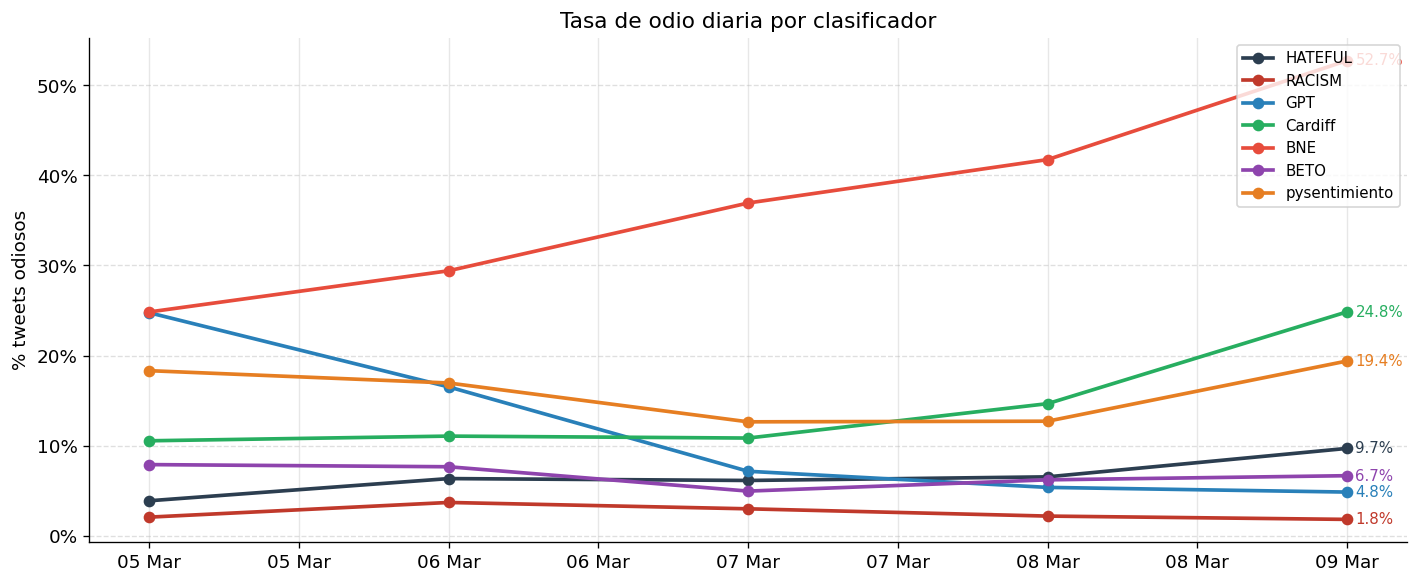

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for m in CLASIF:
    daily = (
        df[df[m].notna()]
        .groupby('fecha_dia')
        .agg(n=('id', 'count'), n_hate=(m, 'sum'))
    )
    rate  = daily['n_hate'] / daily['n'] * 100
    ax.plot(rate.index, rate.values,
            marker='o', linewidth=2.2, markersize=6,
            label=m, color=COLORS[m])
    # Etiqueta en el último punto
    ax.annotate(f'{rate.iloc[-1]:.1f}%',
                xy=(rate.index[-1], rate.iloc[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, color=COLORS[m], va='center')

ax.set_ylabel('% tweets odiosos', fontsize=11)
ax.set_title('Tasa de odio diaria por clasificador', fontsize=13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. Heatmap: tasa de odio por día × clasificador

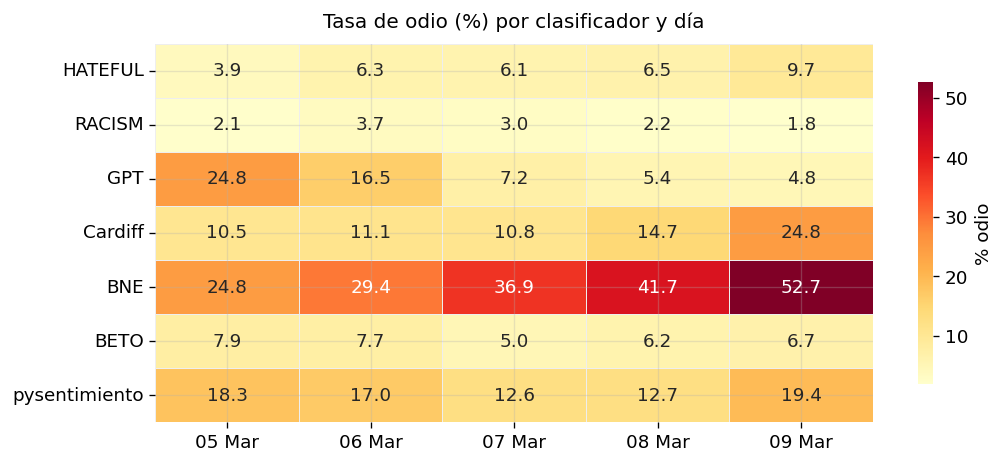

In [6]:
heat_rows = {}
for m in CLASIF:
    daily = df[df[m].notna()].groupby('fecha_dia').agg(n=('id','count'), n_hate=(m,'sum'))
    heat_rows[m] = (daily['n_hate'] / daily['n'] * 100).round(1)

heat_df = pd.DataFrame(heat_rows).T
heat_df.columns = heat_df.columns.strftime('%d %b')

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    heat_df, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='#eee', ax=ax,
    cbar_kws={'label': '% odio', 'shrink': 0.8},
)
ax.set_title('Tasa de odio (%) por clasificador y día', fontsize=12, pad=10)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5c. Acuerdo entre clasificadores

Tres perspectivas complementarias:
- **Cohen's Kappa** (pairwise): acuerdo corregido por azar — robusto con clases desbalanceadas
- **Métricas P/R/F1**: usando `HATEFUL` y `RACISM` como referencia
- **Overlap N-clasificadores**: cuántos tweets son marcados por exactamente N modelos simultáneamente

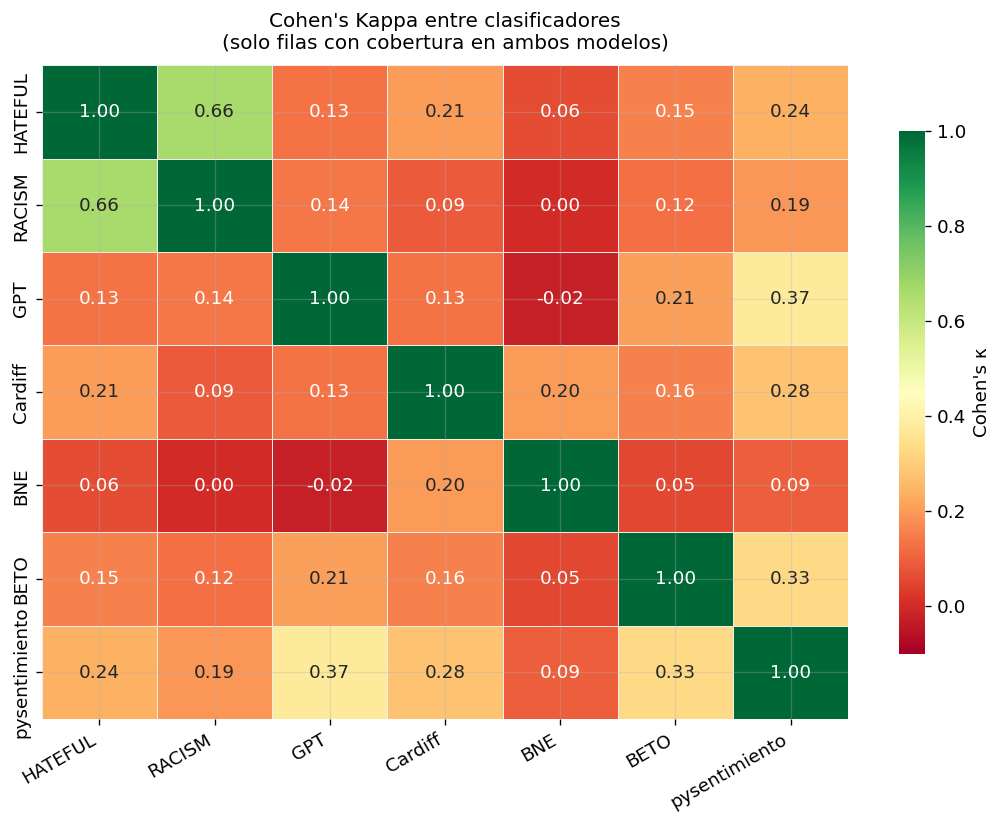


Interpretación κ: <0.2 pobre | 0.2–0.4 débil | 0.4–0.6 moderado | 0.6–0.8 bueno | >0.8 excelente

── Métricas vs HATEFUL (referencia) ──


,N tweets,Precisión,Recall,F1
Clasificador,,,,
RACISM,"246,431",1.000,0.509,0.675
GPT,"246,431",0.130,0.424,0.198
Cardiff,"246,431",0.192,0.412,0.262
BNE,"246,431",0.086,0.493,0.147
BETO,"246,431",0.179,0.243,0.206
pysentimiento,"246,431",0.197,0.611,0.298



── Métricas vs RACISM (referencia) ──


,N tweets,Precisión,Recall,F1
Clasificador,,,,
HATEFUL,"246,431",0.509,1.000,0.675
GPT,"246,431",0.103,0.663,0.179
Cardiff,"246,431",0.079,0.334,0.128
BNE,"246,431",0.028,0.315,0.052
BETO,"246,431",0.109,0.292,0.159
pysentimiento,"246,431",0.132,0.802,0.226


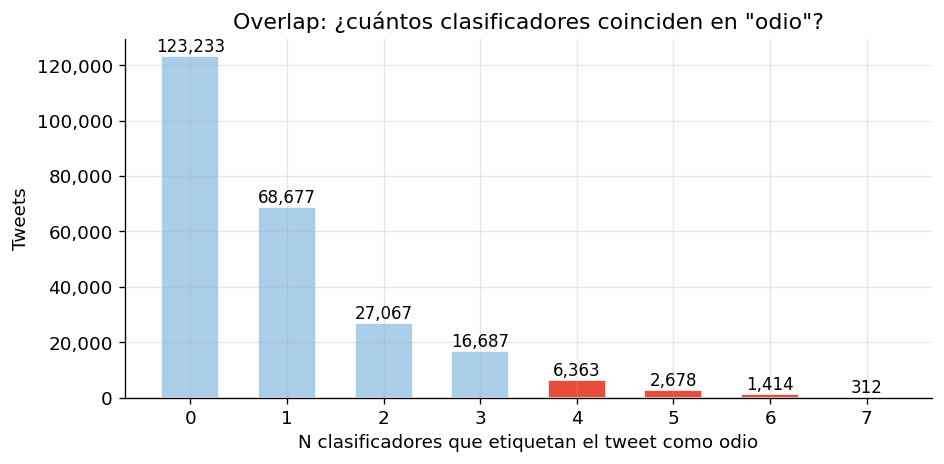


Unánime en odio  (7/7 modelos): 312  (0.13%)
Ninguno detecta odio (0/7 modelos):  123,233  (50.01%)


In [7]:
from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support

# ── 1. Matriz de Cohen's Kappa ─────────────────────────────────────────────────
kappa_mat = pd.DataFrame(index=CLASIF, columns=CLASIF, dtype=float)

for m1 in CLASIF:
    for m2 in CLASIF:
        # Solo filas donde ambos tienen predicción
        mask = df[m1].notna() & df[m2].notna()
        a, b = df.loc[mask, m1].astype(int), df.loc[mask, m2].astype(int)
        if m1 == m2:
            kappa_mat.loc[m1, m2] = 1.0
        elif len(a) == 0 or a.nunique() < 2 or b.nunique() < 2:
            kappa_mat.loc[m1, m2] = np.nan
        else:
            kappa_mat.loc[m1, m2] = cohen_kappa_score(a, b)

fig, ax = plt.subplots(figsize=(9, 7))
mask_nan = kappa_mat.isna()
sns.heatmap(
    kappa_mat.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-0.1, vmax=1.0, linewidths=0.5, linecolor='#eee',
    mask=mask_nan, ax=ax,
    cbar_kws={'label': "Cohen's κ", 'shrink': 0.8},
)
# Marcar NaN explícitamente
for i, m1 in enumerate(CLASIF):
    for j, m2 in enumerate(CLASIF):
        if mask_nan.loc[m1, m2]:
            ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                    fontsize=9, color='#aaa')

ax.set_title("Cohen's Kappa entre clasificadores\n(solo filas con cobertura en ambos modelos)",
             fontsize=12, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_kappa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretación κ: <0.2 pobre | 0.2–0.4 débil | 0.4–0.6 moderado | 0.6–0.8 bueno | >0.8 excelente")

# ── 2. P / R / F1 usando HATEFUL y RACISM como referencia ─────────────────────
print("\n── Métricas vs HATEFUL (referencia) ──")
rows_h = []
for m in CLASIF:
    if m == 'HATEFUL':
        continue
    mask = df['HATEFUL'].notna() & df[m].notna()
    y_true = df.loc[mask, 'HATEFUL'].astype(int)
    y_pred = df.loc[mask, m].astype(int)
    if len(y_true) == 0:
        continue
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, pos_label=1,
                                                  average='binary', zero_division=0)
    n = mask.sum()
    rows_h.append({'Clasificador': m, 'N tweets': n,
                   'Precisión': p, 'Recall': r, 'F1': f})

df_h = pd.DataFrame(rows_h).set_index('Clasificador')
display(
    df_h.style
    .format({'N tweets': '{:,}', 'Precisión': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'})
    .background_gradient(subset=['F1'], cmap='Greens')
    .background_gradient(subset=['Precisión'], cmap='Blues')
    .background_gradient(subset=['Recall'], cmap='Oranges')
    .set_caption('Métricas vs HATEFUL como referencia')
)

print("\n── Métricas vs RACISM (referencia) ──")
rows_r = []
for m in CLASIF:
    if m == 'RACISM':
        continue
    mask = df['RACISM'].notna() & df[m].notna()
    y_true = df.loc[mask, 'RACISM'].astype(int)
    y_pred = df.loc[mask, m].astype(int)
    if len(y_true) == 0:
        continue
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, pos_label=1,
                                                  average='binary', zero_division=0)
    n = mask.sum()
    rows_r.append({'Clasificador': m, 'N tweets': n,
                   'Precisión': p, 'Recall': r, 'F1': f})

df_r = pd.DataFrame(rows_r).set_index('Clasificador')
display(
    df_r.style
    .format({'N tweets': '{:,}', 'Precisión': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'})
    .background_gradient(subset=['F1'], cmap='Greens')
    .background_gradient(subset=['Precisión'], cmap='Blues')
    .background_gradient(subset=['Recall'], cmap='Oranges')
    .set_caption('Métricas vs RACISM como referencia')
)

# ── 3. Overlap: tweets marcados por N clasificadores ──────────────────────────
CLASIF_FULL = CLASIF  # todos los clasificadores tienen cobertura completa
df_full = df[CLASIF_FULL].copy().apply(pd.to_numeric, errors='coerce')

df['n_clasif_hate'] = df_full.sum(axis=1, skipna=True).astype(int)
overlap = df['n_clasif_hate'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(overlap.index, overlap.values,
              color=[COLORS.get('BNE') if i >= 4 else '#aacde8' for i in overlap.index],
              width=0.6, edgecolor='white')
for bar, val in zip(bars, overlap.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('N clasificadores que etiquetan el tweet como odio')
ax.set_ylabel('Tweets')
ax.set_title('Overlap: ¿cuántos clasificadores coinciden en "odio"?')
ax.set_xticks(overlap.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

pct_unanime = int((df['n_clasif_hate'] == len(CLASIF_FULL)).sum())
pct_cero    = int((df['n_clasif_hate'] == 0).sum())
print(f"\nUnánime en odio  ({len(CLASIF_FULL)}/{len(CLASIF_FULL)} modelos): {pct_unanime:,}  ({pct_unanime/len(df)*100:.2f}%)")
print(f"Ninguno detecta odio (0/{len(CLASIF_FULL)} modelos):  {pct_cero:,}  ({pct_cero/len(df)*100:.2f}%)")

## 6. Distribución por categoría original

Conteo de tweets con cada etiqueta individual del clasificador contextual (piuba-bigdata/beto).

Tweets con ≥1 etiqueta (incluyendo CALLS): 13,121
Tweets HATEFUL (sin CALLS):                13,006


,tweets,% del total
etiqueta,,
RACISM,"6,624",2.69%
POLITICS,"2,599",1.05%
CALLS,"1,933",0.78%
WOMEN,"1,908",0.77%
APPEARANCE,"1,054",0.43%
CLASS,777,0.32%
CRIMINAL,717,0.29%
DISABLED,665,0.27%
LGBTI,126,0.05%


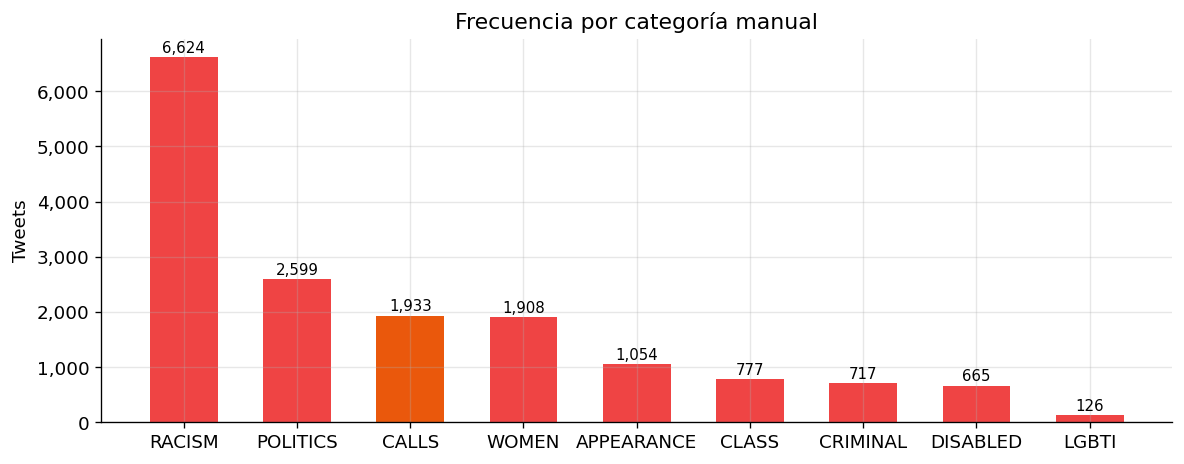

In [8]:
counts = df[LABEL_COLS].astype(float).sum().sort_values(ascending=False)
pcts   = (counts / len(df) * 100).round(2)

label_df = pd.DataFrame({'tweets': counts.astype(int), '% del total': pcts})
label_df.index.name = 'etiqueta'

print(f"Tweets con ≥1 etiqueta (incluyendo CALLS): {int((df['n_labels'] > 0).sum()):,}")
print(f"Tweets HATEFUL (sin CALLS):                {int((df['HATEFUL'] == 1).sum()):,}")

display(
    label_df.style
    .format({'tweets': '{:,}', '% del total': '{:.2f}%'})
    .background_gradient(subset=['tweets'], cmap='Reds')
    .set_caption('Tweets por categoría manual de discurso de odio')
)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
colors  = ['#ef4444' if l != 'CALLS' else '#ea580c' for l in counts.index]
ax.bar(counts.index, counts.values, color=colors, width=0.6)
for i, (lbl, val) in enumerate(counts.items()):
    ax.text(i, val + 30, f'{int(val):,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Tweets')
ax.set_title('Frecuencia por categoría manual')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_labels.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Tipos de tweet por clasificador

Tasa de odio según el tipo de tweet (RT, Mención/Reply, Original) para cada clasificador.

,total,HATEFUL,RACISM,GPT,Cardiff,BNE,BETO,pysentimiento
tipo,,,,,,,,
Mención/Reply,"32,339",8.8%,3.1%,13.9%,19.8%,53.7%,8.9%,22.1%
Original,"27,904",7.1%,3.1%,12.6%,16.6%,43.3%,9.9%,16.1%
RT,"186,188",4.4%,2.6%,18.6%,9.0%,24.1%,6.5%,15.4%


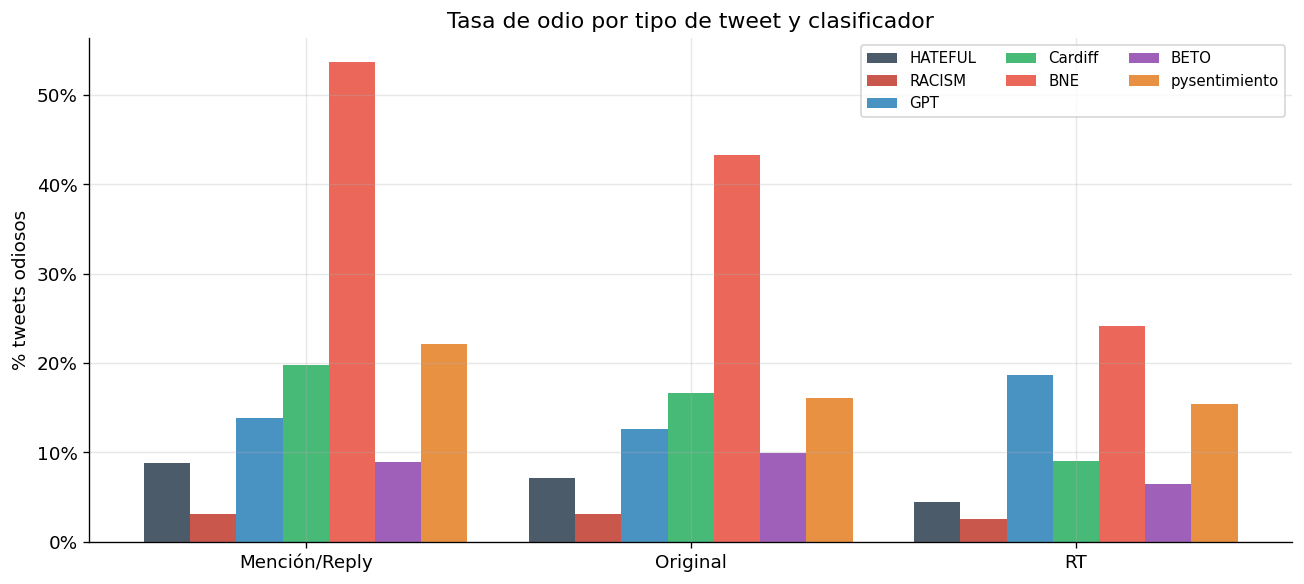

In [9]:
# Tabla: % odio por tipo × clasificador
tipo_counts = df.groupby('tipo').size().rename('total')
tipo_hate   = df.groupby('tipo')[CLASIF].apply(lambda g: (g == 1).mean() * 100).round(1)
tipo_df     = tipo_hate.join(tipo_counts)
tipo_df.insert(0, 'total', tipo_df.pop('total'))

display(
    tipo_df.style
    .format({'total': '{:,}', **{m: '{:.1f}%' for m in CLASIF}})
    .background_gradient(subset=CLASIF, cmap='Reds', axis=None)
    .set_caption('% tweets odiosos por tipo de tweet y clasificador')
)

# Gráfico de barras agrupadas
tipos  = tipo_df.index.tolist()
x      = np.arange(len(tipos))
n_mod  = len(CLASIF)
w      = 0.12

fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(CLASIF):
    offset = (i - n_mod / 2 + 0.5) * w
    bars = ax.bar(x + offset, tipo_df[m], width=w, label=m, color=COLORS[m], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(tipos, fontsize=11)
ax.set_ylabel('% tweets odiosos')
ax.set_title('Tasa de odio por tipo de tweet y clasificador')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_tipos.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b. HATEFUL vs RACISM por tipo de tweet

Foco en las dos etiquetas manuales principales: **HATEFUL** (odio agregado) y **RACISM** (xenofobia/racismo).  
Se muestra tanto la **tasa** (% sobre el total de cada tipo) como el **conteo absoluto**.


In [ ]:
# ── Conteos y tasas HATEFUL / RACISM por tipo ───────────────────────────
hr = (
    df.groupby('tipo')
    .agg(
        total      =('id',      'count'),
        n_hateful  =('HATEFUL', 'sum'),
        n_racism   =('RACISM',  'sum'),
    )
)
hr['pct_hateful'] = (hr['n_hateful'] / hr['total'] * 100).round(1)
hr['pct_racism']  = (hr['n_racism']  / hr['total'] * 100).round(1)
hr = hr.sort_values('total', ascending=False)

display(
    hr.rename(columns={
        'total': 'total', 'n_hateful': 'HATEFUL', 'n_racism': 'RACISM',
        'pct_hateful': '% HATEFUL', 'pct_racism': '% RACISM'
    })
    .style
    .format({'total': '{:,}', 'HATEFUL': '{:,}', 'RACISM': '{:,}',
             '% HATEFUL': '{:.1f}%', '% RACISM': '{:.1f}%'})
    .background_gradient(subset=['% HATEFUL', '% RACISM'], cmap='Reds', axis=None)
    .set_caption('HATEFUL y RACISM por tipo de tweet')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]}])
)

# ── Gráfico doble: tasa y conteo absoluto ────────────────────────────────
tipos = hr.index.tolist()
x     = np.arange(len(tipos))
w     = 0.3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: porcentajes
ax = axes[0]
ax.bar(x - w/2, hr['pct_hateful'], width=w, color=COLORS['HATEFUL'], alpha=0.85, label='HATEFUL')
ax.bar(x + w/2, hr['pct_racism'],  width=w, color=COLORS['RACISM'],  alpha=0.85, label='RACISM')
for j, t in enumerate(tipos):
    ax.text(j - w/2, hr.loc[t, 'pct_hateful'] + 0.3,
            f"{hr.loc[t,'pct_hateful']:.1f}%", ha='center', fontsize=9)
    ax.text(j + w/2, hr.loc[t, 'pct_racism']  + 0.3,
            f"{hr.loc[t,'pct_racism']:.1f}%",  ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(tipos)
ax.set_ylabel('% del total')
ax.set_title('Tasa HATEFUL y RACISM por tipo')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()

# Panel derecho: conteos absolutos
ax2 = axes[1]
ax2.bar(x - w/2, hr['n_hateful'], width=w, color=COLORS['HATEFUL'], alpha=0.85, label='HATEFUL')
ax2.bar(x + w/2, hr['n_racism'],  width=w, color=COLORS['RACISM'],  alpha=0.85, label='RACISM')
for j, t in enumerate(tipos):
    ax2.text(j - w/2, hr.loc[t, 'n_hateful'] + hr['n_hateful'].max() * 0.01,
             f"{hr.loc[t,'n_hateful']:,}", ha='center', fontsize=9)
    ax2.text(j + w/2, hr.loc[t, 'n_racism']  + hr['n_racism'].max()  * 0.01,
             f"{hr.loc[t,'n_racism']:,}",  ha='center', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(tipos)
ax2.set_ylabel('Cantidad de tweets')
ax2.set_title('Tweets HATEFUL y RACISM por tipo (absoluto)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax2.legend()

fig.suptitle('HATEFUL vs RACISM — distribución por tipo de tweet', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/EDA_clasif_tipos_hr.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Top RTs más retuiteados

Tweets más retuiteados en el dataset, con la etiqueta de cada clasificador.

In [10]:
TOP_N = 15

top_rts = (
    df[df['tipo'] == 'RT']
    .groupby('text')
    .agg(
        n_rts      = ('id',        'count'),
        fecha_min  = ('fecha_dia', 'min'),
        fecha_max  = ('fecha_dia', 'max'),
        **{m: (m, 'first') for m in CLASIF},
    )
    .reset_index()
    .sort_values('n_rts', ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

def _model_badges(row):
    parts = []
    for m in CLASIF:
        try:
            if pd.notna(row[m]) and int(row[m]) == 1:
                parts.append(
                    f'<span style="background:{COLORS[m]};color:#fff;padding:2px 7px;'
                    f'border-radius:10px;font-size:11px;margin-right:3px;">{m}</span>'
                )
        except Exception:
            pass
    return ''.join(parts) or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'

cards = []
for i, row in top_rts.iterrows():
    texto  = htmllib.escape(str(row['text'])[:200])
    span   = int((row['fecha_max'] - row['fecha_min']).days)
    fechas = f"{row['fecha_min'].strftime('%d %b')} → {row['fecha_max'].strftime('%d %b')}" if span > 0 else row['fecha_min'].strftime('%d %b')
    badges = _model_badges(row)
    cards.append(
        f'<div style="background:#fff;border:1px solid #dde;border-left:4px solid #e74c3c;'
        f'border-radius:8px;padding:10px 14px;margin:6px 0;">'
        f'  <div style="display:flex;justify-content:space-between;margin-bottom:6px;">'
        f'    <span style="font-weight:bold;color:#222;font-size:13px;">#{i+1} — {row["n_rts"]:,} RTs</span>'
        f'    <span style="font-size:11px;color:#888;">📅 {fechas}</span>'
        f'  </div>'
        f'  <div style="background:#fff;font-size:13px;color:#222;line-height:1.5;margin-bottom:7px;">{texto}…</div>'
        f'  <div style="background:#fff;">{badges}</div>'
        f'</div>'
    )

display(HTML(
    '<h4 style="font-family:Arial;color:#222;">Top RTs más retuiteados</h4>' +
    ''.join(cards)
))

## 9. Usuarios más retuiteados

Para cada usuario extraído de los RTs (`RT @usuario:`): cantidad de RTs en el dataset y tasa de odio según cada clasificador.

In [11]:
TOP_USERS = 30

user_stats = (
    df[df['rt_user'].notna()]
    .groupby('rt_user')
    .agg(
        n_rts = ('id', 'count'),
        **{m: (m, lambda x: (x == 1).mean() * 100) for m in CLASIF},
    )
    .reset_index()
    .sort_values('n_rts', ascending=False)
    .head(TOP_USERS)
)

display(
    user_stats.set_index('rt_user')
    .style
    .format({'n_rts': '{:,.0f}', **{m: '{:.1f}%' for m in CLASIF}})
    .background_gradient(subset=['n_rts'],   cmap='Blues')
    .background_gradient(subset=['HATEFUL'], cmap='Reds')
    .background_gradient(subset=['BNE'],     cmap='Oranges')
    .set_caption(f'Top {TOP_USERS} usuarios más retuiteados — tasa de odio por clasificador')
)

,n_rts,HATEFUL,RACISM,GPT,Cardiff,BNE,BETO,pysentimiento
rt_user,,,,,,,,
PatoBullrich,"6,466",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
maquialifraco,"6,447",0.0%,0.0%,99.9%,0.3%,0.4%,0.3%,0.3%
MiguelPichetto,"5,090",0.0%,0.0%,72.2%,0.0%,0.0%,100.0%,100.0%
JorgeFaurie,"3,079",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
jorgemacri,"2,899",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
todonoticias,"2,826",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
florenciarietto,"2,408",2.1%,2.0%,0.0%,2.0%,39.9%,0.0%,0.1%
luispetri,"2,109",0.0%,0.0%,12.0%,0.0%,0.0%,0.0%,3.0%
rctagliaferro,"2,012",0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%


## 10. Exploración por keyword

Busca tweets que contengan alguno de los keywords y estén etiquetados como odiosos según el filtro manual seleccionado.
Muestra tarjetas individuales con fondo blanco y badges por modelo.

In [12]:
# ── Configuración ─────────────────────────────────────────────────────────────
SEED_KW     = 42
N_TWEETS_KW = 10
KEYWORDS    = ['DNU', 'vacuna']   # lista OR
FILTRO_KW   = 'HATEFUL'           # 'HATEFUL', 'RACISM', o None

# ── Filtrar ───────────────────────────────────────────────────────────────────
pattern = '|'.join(KEYWORDS)
mask_kw = df['text'].str.contains(pattern, case=False, na=False, regex=True)
mask_hate = df[FILTRO_KW] == 1 if FILTRO_KW else pd.Series(True, index=df.index)

filtered  = df[mask_kw & mask_hate].drop_duplicates(subset=['text'])

print(f"Tweets con ({pattern}):       {mask_kw.sum():,}")
print(f"  con {FILTRO_KW}=1 (dedup): {len(filtered):,}")

if len(filtered) == 0:
    print('Sin resultados.')
else:
    muestra = filtered.sample(min(N_TWEETS_KW, len(filtered)), random_state=SEED_KW)

    output_html = (
        f'<h4 style="font-family:Arial;color:#222;margin-bottom:12px;">'
        f'Tweets odiosos con "{pattern}" — SEED={SEED_KW} '
        f'<span style="font-size:12px;color:#888;">({len(filtered):,} únicos)</span></h4>'
    )

    for _, row in muestra.iterrows():
        text   = htmllib.escape(str(row['text'])[:400])
        date   = str(row.get('fecha_dia', ''))[:10]
        badges = _model_badges(row)
        tipo   = '🔁' if str(row['text']).startswith('RT @') else '🐦'
        output_html += (
            f'<div style="font-family:Arial;background:#fff;border:1px solid #ccd;'
            f'border-radius:10px;margin-bottom:10px;overflow:hidden;">'
            f'  <div style="background:#f4f6f9;padding:5px 14px;font-size:11px;color:#666;'
            f'border-bottom:1px solid #dde;">{tipo} {date}</div>'
            f'  <div style="background:#fff;padding:10px 14px;font-size:13px;color:#222;'
            f'line-height:1.6;">{text}</div>'
            f'  <div style="background:#fff;padding:5px 14px 10px;">{badges}</div>'
            f'</div>'
        )

    display(HTML(output_html))

Tweets con (DNU|vacuna):       6,664
  con HATEFUL=1 (dedup): 59


## 11. Exploración de hilos de replies

Muestra el tweet raíz y sus replies del dataset. Se filtra para que al menos un reply esté clasificado como odioso según el modelo elegido.

In [13]:
# ── Configuración ─────────────────────────────────────────────────────────────
SEED_HILO   = 42        # ← cambiar para ver distintos ejemplos
N_HILOS     = 3         # número de hilos a mostrar
FILTRO_HILO = 'HATEFUL' # clasificador para filtrar hilos con ≥1 reply odiosa

# ── Preparar índice por ID y detectar replies ──────────────────────────────────
# Los IDs pueden estar como float ("1234.0") → convertir a int string limpio
df['_id_str'] = pd.to_numeric(df['id'], errors='coerce').astype('Int64').astype(str)
id_index      = df.set_index('_id_str')

replies = df[df['in_reply_to_status_id'].notna()].copy()
replies['_parent'] = (
    pd.to_numeric(replies['in_reply_to_status_id'], errors='coerce')
    .astype('Int64').astype(str)
)
# Quedarse solo con replies cuya raíz también está en el dataset
replies_in_ds = replies[replies['_parent'].isin(id_index.index) & (replies['_parent'] != '<NA>')]

root_ids = replies_in_ds['_parent'].unique()
print(f"Replies con raíz en el dataset: {len(replies_in_ds):,}")
print(f"Tweets raíz únicos:             {len(root_ids):,}")

# Filtrar hilos donde ≥1 reply tiene FILTRO_HILO = 1
root_ids_fil = [
    rid for rid in root_ids
    if (replies_in_ds[replies_in_ds['_parent'] == rid][FILTRO_HILO] == 1).any()
]
print(f"Hilos con ≥1 reply {FILTRO_HILO}=1: {len(root_ids_fil):,}")

muestra_hilos = (
    pd.Series(root_ids_fil)
    .sample(min(N_HILOS, len(root_ids_fil)), random_state=SEED_HILO)
    .tolist()
)

# ── Función de tarjeta para hilo ───────────────────────────────────────────────
def _thread_card(row, is_root=False):
    badges = _model_badges(row)
    fecha  = str(row.get('fecha_dia', ''))[:10]
    texto  = htmllib.escape(str(row['text'])[:300])
    bg     = '#f0f9ff' if is_root else '#ffffff'
    border = '2px solid #3b82f6' if is_root else '1px solid #e5e7eb'
    prefix = '<b>🔵 RAÍZ</b>' if is_root else '&nbsp;↳'
    return (
        f'<div style="background:{bg};border:{border};border-radius:8px;'
        f'padding:10px 14px;margin:6px 0;">'
        f'<div style="font-size:11px;color:#6b7280;margin-bottom:4px;">{prefix} 📅 {fecha}</div>'
        f'<div style="background:{bg};font-size:13px;color:#222;line-height:1.5;margin-bottom:6px;">{texto}</div>'
        f'<div style="background:{bg};">{badges}</div>'
        f'</div>'
    )

# ── Renderizar hilos ───────────────────────────────────────────────────────────
html_parts = []
for root_id in muestra_hilos:
    root  = id_index.loc[root_id]
    hijos = replies_in_ds[replies_in_ds['_parent'] == root_id]
    html_parts.append(
        f'<div style="font-family:Arial;border:2px solid #cbd5e1;border-radius:10px;'
        f'padding:14px;margin:16px 0;">'
        f'<div style="font-size:12px;color:#94a3b8;margin-bottom:6px;">'
        f'HILO — {len(hijos):,} reply/s en el dataset &nbsp;|&nbsp; '
        f'filtro: <b>{FILTRO_HILO}</b> &nbsp;|&nbsp; SEED={SEED_HILO}'
        f'</div>'
        + _thread_card(root, is_root=True)
        + ''.join(_thread_card(h, is_root=False) for _, h in hijos.iterrows())
        + '</div>'
    )

display(HTML('\n'.join(html_parts)))

Replies con raíz en el dataset: 504
Tweets raíz únicos:             253
Hilos con ≥1 reply HATEFUL=1: 37


## 12. Búsqueda por usuario mencionado

Tweets que mencionan a uno o más usuarios específicos. Muestra cuántos hay, la tasa de odio por clasificador para esa muestra, y ejemplos con badges de todos los modelos.

> ⚠️ El dataset no tiene columna de autor propio. Para **RTs** se extrae el autor original (`RT @usuario:`). Para tweets directos y replies el autor es desconocido — pero sí podemos buscar a quiénes se *menciona*.

In [14]:
# ── Configuración ─────────────────────────────────────────────────────────────
USUARIOS_BUSCAR = ['baradit', 'madorni']  # ← lista de usuarios (sin @)
N_EJEMPLOS_USER = 10
SEED_USER       = 42

# ── Filtrar tweets que mencionan al menos uno de los usuarios ──────────────────
patron = '|'.join([rf'@{u}' for u in USUARIOS_BUSCAR])
mask   = df['text'].str.contains(patron, case=False, na=False, regex=True)
df_men = df[mask].copy()

# Contar veces retuiteado por texto único y colapsar duplicados
rt_counts = df_men.groupby('text')['id'].nunique().rename('n_rts').reset_index()
df_unicos = (
    df_men
    .drop_duplicates(subset='text', keep='first')
    .merge(rt_counts, on='text', how='left')
)

print(f"Tweets que mencionan {USUARIOS_BUSCAR}: {len(df_men):,}  →  textos únicos: {len(df_unicos):,}")
for u in USUARIOS_BUSCAR:
    n_tot = df['text'].str.contains(f'@{u}', case=False, na=False).sum()
    n_uni = df[df['text'].str.contains(f'@{u}', case=False, na=False)].drop_duplicates('text').shape[0]
    print(f"  @{u}: {n_tot:,} apariciones  /  {n_uni:,} textos únicos")

# ── Tasa de odio por clasificador en tweets con mención ───────────────────────
print(f"\nTasa de odio en textos únicos con mención ({len(df_unicos):,}):")
rows_men = []
for m in CLASIF:
    n_cov  = int(df_unicos[m].notna().sum())
    n_hate = int((df_unicos[m] == 1).sum())
    rows_men.append({'Clasificador': m, 'Cubiertos': n_cov, 'Odiosos': n_hate,
                     '% odio': n_hate / n_cov * 100 if n_cov else 0})
display(
    pd.DataFrame(rows_men).set_index('Clasificador')
    .style
    .format({'Cubiertos': '{:,}', 'Odiosos': '{:,}', '% odio': '{:.1f}%'})
    .background_gradient(subset=['% odio'], cmap='Reds')
    .set_caption(f'Tasa de odio por clasificador — tweets con mención a {USUARIOS_BUSCAR}')
)

# ── Muestra de ejemplos ────────────────────────────────────────────────────────
muestra_u = df_unicos.sample(min(N_EJEMPLOS_USER, len(df_unicos)), random_state=SEED_USER)

html_parts = []
for _, row in muestra_u.iterrows():
    # Destacar en azul los usuarios buscados
    texto = htmllib.escape(str(row['text'])[:320])
    for u in USUARIOS_BUSCAR:
        texto = re.sub(
            rf'(@{re.escape(u)})',
            r'<b style="color:#2563eb">\1</b>',
            texto, flags=re.IGNORECASE
        )
    badges  = _model_badges(row)
    fecha   = str(row.get('fecha_dia', ''))[:10]
    is_rt   = str(row['text']).startswith('RT')
    tipo    = '🔁 RT' if is_rt else '💬 Tweet'
    n_rts   = int(row.get('n_rts', 1))
    rt_tag  = (
        f' <span style="background:#f1f5f9;border:1px solid #cbd5e1;border-radius:4px;'
        f'padding:2px 8px;font-size:11px;">🔁 {n_rts:,}×</span>'
        if n_rts > 1 else ''
    )
    html_parts.append(
        f'<div style="font-family:Arial;background:#fff;border:1px solid #e5e7eb;'
        f'border-radius:8px;padding:10px 14px;margin:6px 0;">'
        f'<div style="font-size:11px;color:#6b7280;margin-bottom:4px;">📅 {fecha} &nbsp; {tipo}{rt_tag}</div>'
        f'<div style="background:#fff;font-size:13px;color:#222;line-height:1.5;margin-bottom:6px;">{texto}</div>'
        f'<div style="background:#fff;">{badges}</div>'
        f'</div>'
    )

display(HTML(
    f'<h4 style="font-family:Arial;color:#222;">Ejemplos — mención a {USUARIOS_BUSCAR} '
    f'<span style="font-size:12px;color:#888;">SEED={SEED_USER}</span></h4>'
    + '\n'.join(html_parts)
))

Tweets que mencionan ['baradit', 'madorni']: 1,365  →  textos únicos: 60
  @baradit: 22 apariciones  /  14 textos únicos
  @madorni: 1,343 apariciones  /  46 textos únicos

Tasa de odio en textos únicos con mención (60):


,Cubiertos,Odiosos,% odio
Clasificador,,,
HATEFUL,60,12,20.0%
RACISM,60,8,13.3%
GPT,60,10,16.7%
Cardiff,60,5,8.3%
BNE,60,27,45.0%
BETO,60,5,8.3%
pysentimiento,60,14,23.3%


## 13. Nubes de palabras por clasificador

Vocabulario de los tweets etiquetados como **odiosos** por cada modelo. Se eliminan URLs, menciones (`@`), hashtags (`#`) y stop words del español y castellano rioplatense.

- **13a** — Nube global: todos los tweets odiosos según ese modelo.
- **13b** — Detecciones exclusivas: solo tweets marcados por ese modelo pero no por ningún otro. Permite ver qué vocabulario diferencia a cada clasificador.
- **13c** — Frecuencia de palabras: tabla top-30 y gráfico de barras top-20.

In [15]:
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'wordcloud'], check=True)
    from wordcloud import WordCloud

# ── Stop words: español + rioplatense + artefactos Twitter ────────────────────
_STOPWORDS_WC = {
    # Artículos, preposiciones, conjunciones
    'a', 'al', 'ante', 'bajo', 'con', 'contra', 'de', 'del', 'desde',
    'durante', 'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre',
    'esa', 'esas', 'ese', 'eso', 'esos', 'esta', 'estas', 'este', 'esto',
    'estos', 'hacia', 'hasta', 'la', 'las', 'le', 'les', 'lo', 'los',
    'me', 'mi', 'mis', 'ni', 'no', 'nos', 'o', 'para', 'pero', 'por',
    'que', 'qué', 'se', 'si', 'sí', 'sin', 'sobre', 'su', 'sus', 'te',
    'tu', 'tú', 'un', 'una', 'uno', 'unas', 'unos', 'ya', 'yo',
    # Verbos auxiliares y comunes
    'ser', 'estar', 'tener', 'hacer', 'poder', 'querer', 'saber', 'ir',
    'fue', 'fueron', 'era', 'eran', 'es', 'son', 'hay', 'hubo', 'han',
    'ha', 'he', 'tiene', 'tienen', 'tengo', 'van', 'va', 'ver', 'hizo',
    'hace', 'hacen', 'iba', 'iban', 'dijo', 'dice', 'deben', 'debe',
    'pueden', 'puede', 'quiere', 'quieren', 'viven', 'vive',
    # Adverbios, determinantes y conectores
    'así', 'bien', 'igual', 'mismo', 'tampoco', 'aunque', 'además',
    'porque', 'cuando', 'donde', 'aquí', 'acá', 'allá', 'allí', 'hoy',
    'ahora', 'antes', 'después', 'siempre', 'nunca', 'cada', 'más',
    'muy', 'nada', 'sino', 'mucho', 'muchos', 'poco', 'tanto', 'tal',
    'vez', 'otro', 'otros', 'otra', 'otras', 'algunas', 'algunos', 'todo',
    'todos', 'toda', 'algún', 'alguna', 'también', 'tan', 'menos', 'casi',
    'solo', 'sólo', 'sola', 'mismo', 'misma', 'quien', 'como', 'quién',
    # Castellano rioplatense / coloquial
    'che', 'vos', 'dale', 're', 'onda', 'tipo', 'loco', 'loca', 'bueno',
    'bue', 'claro', 'capaz', 'obvio', 'posta', 'jaja', 'jajaja',
    'jajajaja', 'jeje', 'jajaj', 'jaj', 'ojo', 'porfa', 'osea', 'pff',
    'uff', 'ugh', 'mmm', 'aca', 'alla', 'ahi', 'encima',
    # Artefactos Twitter / medios
    'clarincom', 'lanacion', 'infobae', 'pagina', 'cronica', 'perfilcom',
    'rt', 'via', 'amp', 'co',
}

def _limpiar_tweet(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)          # URLs
    texto = re.sub(r'@\w+', '', texto)                     # menciones
    texto = re.sub(r'#\w+', '', texto)                     # hashtags
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)       # solo letras
    texto = re.sub(r'\b\w{1,2}\b', ' ', texto)            # palabras ≤2 letras
    return re.sub(r'\s+', ' ', texto).strip()

def _make_wc(corpus, title, ax, cmap='Reds', max_words=120):
    words = [w for w in corpus.split() if w not in _STOPWORDS_WC and len(w) >= 3]
    if len(words) < 10:
        ax.text(0.5, 0.5, 'Sin datos suficientes', ha='center', va='center',
                fontsize=12, color='#aaa', transform=ax.transAxes)
        ax.axis('off')
        ax.set_title(title, fontsize=10, pad=8)
        return
    wc = WordCloud(
        width=900, height=420,
        background_color='white',
        colormap=cmap,
        max_words=max_words,
        min_word_length=3,
        collocations=False,
        prefer_horizontal=0.85,
    ).generate(' '.join(words))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=11, pad=10, fontweight='bold')
    ax.axis('off')

### 13a. Nube global por clasificador

Todos los tweets marcados como odiosos por cada modelo. El color de la nube es distinto por modelo para facilitar la comparación visual.

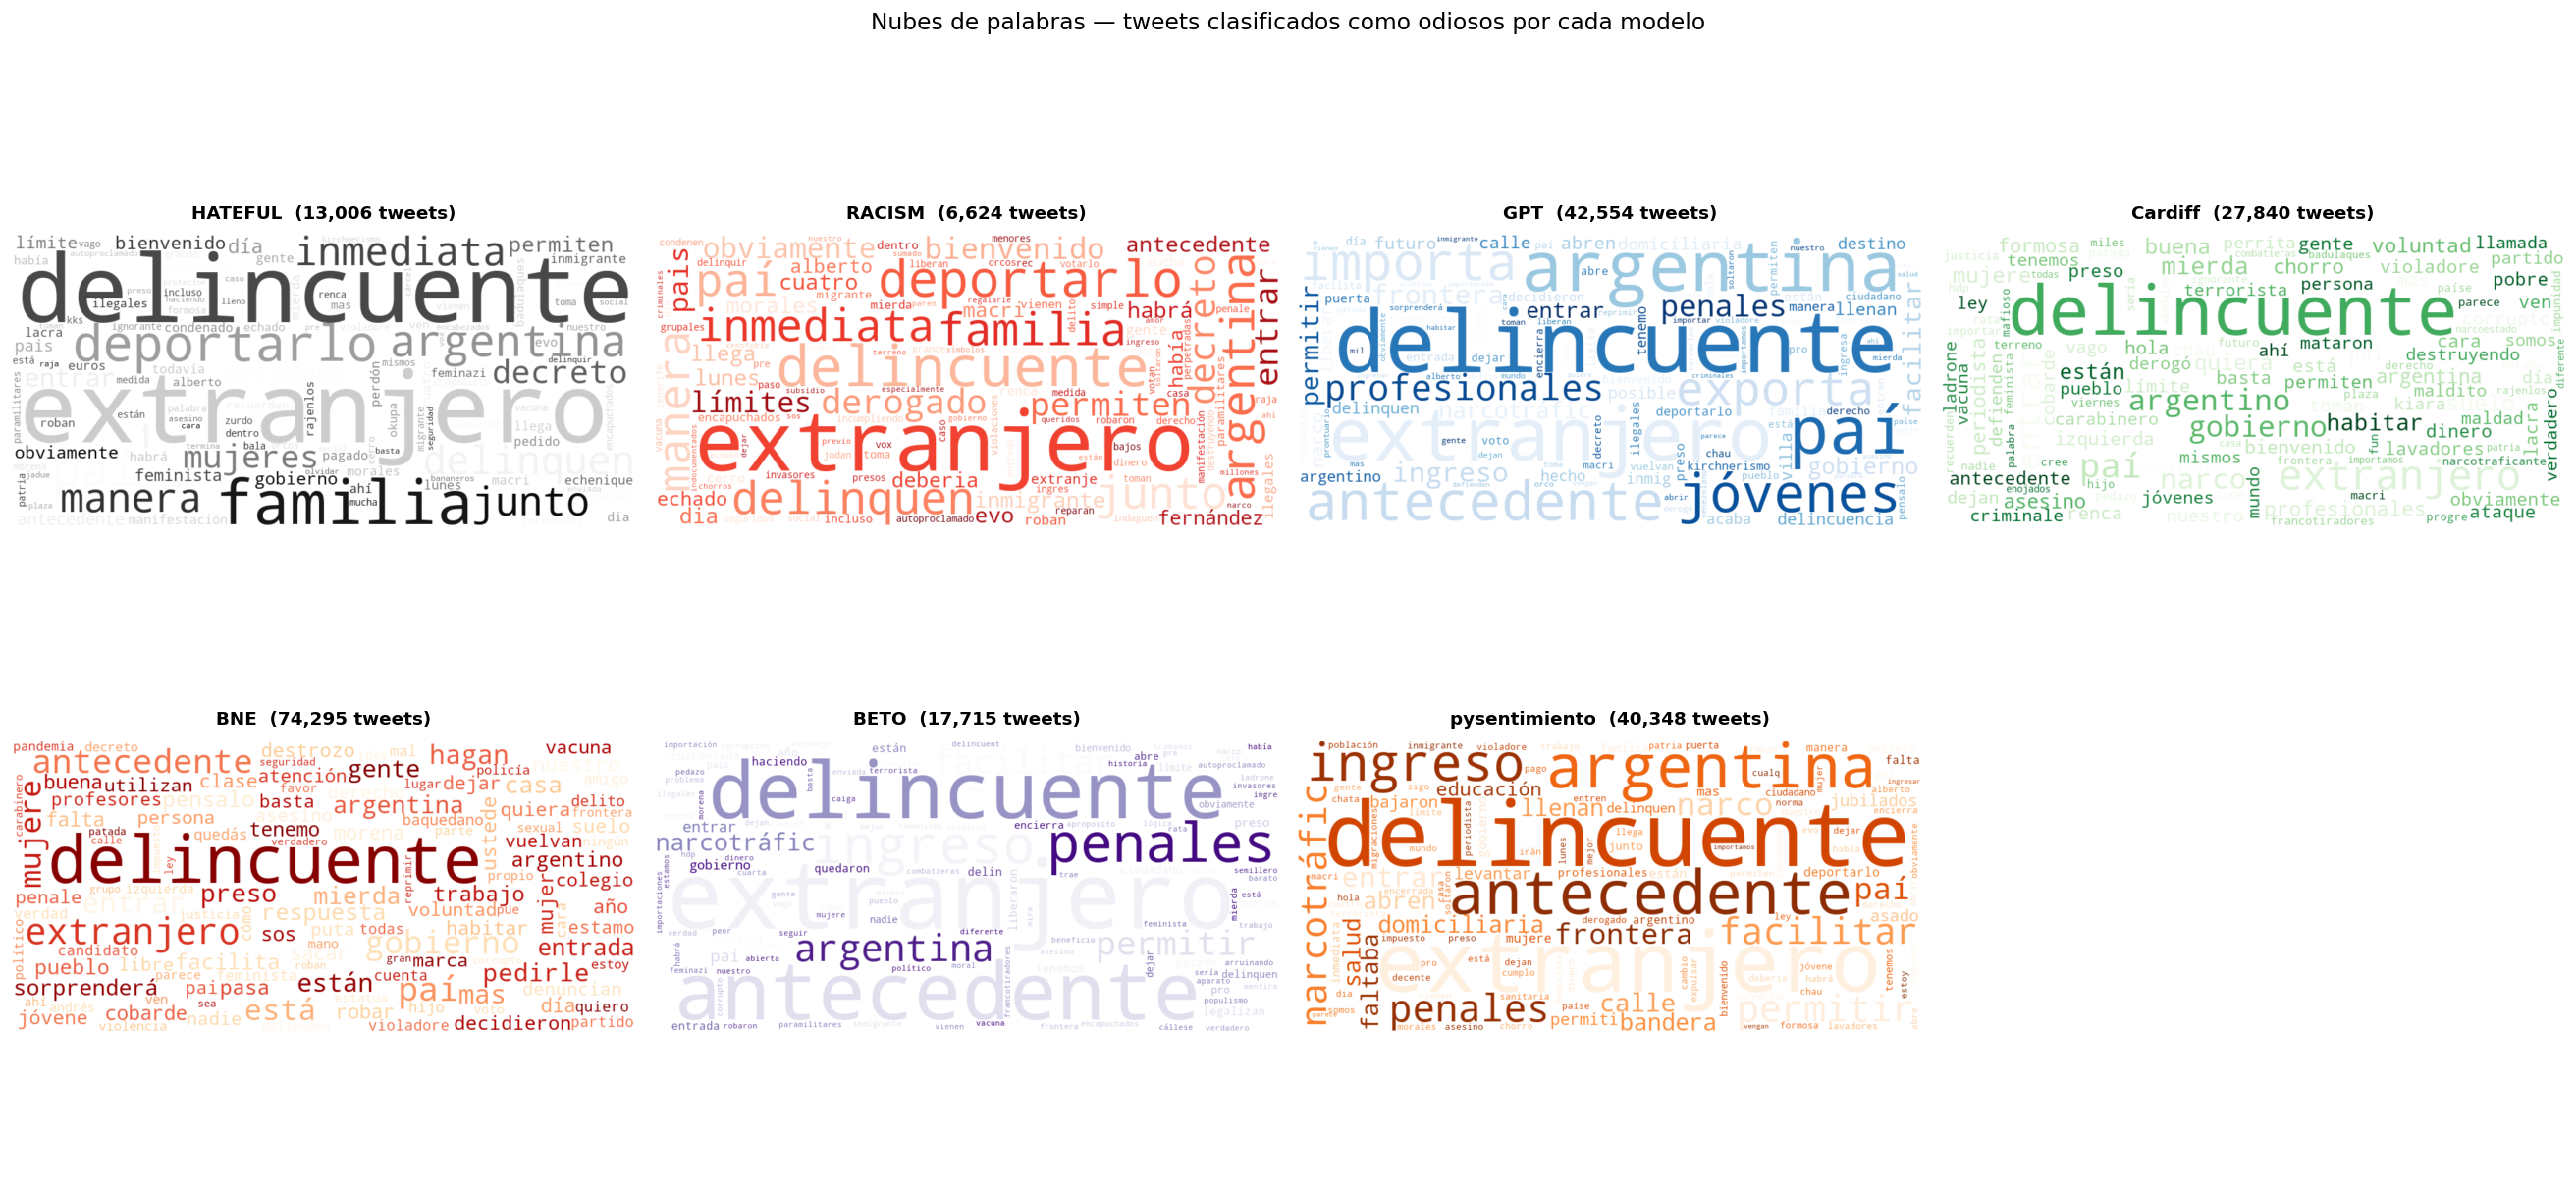

In [16]:
# ── Limpiar textos (columna temporal) ─────────────────────────────────────────
df['_texto_limpio'] = df['text'].apply(_limpiar_tweet)

# ── Colormaps por clasificador ─────────────────────────────────────────────────
CMAPS_WC = {
    'HATEFUL':       'Greys',
    'RACISM':        'Reds',
    'GPT':           'Blues',
    'Cardiff':       'Greens',
    'BNE':           'OrRd',
    'BETO':          'Purples',
    'pysentimiento': 'Oranges',
}

# ── Grid 4×2: una nube por clasificador (última celda vacía) ──────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, m in enumerate(CLASIF):
    hate_mask = df[m] == 1
    n_hate = hate_mask.sum()
    corpus = ' '.join(df.loc[hate_mask, '_texto_limpio'])
    title  = f'{m}  ({n_hate:,} tweets)'
    _make_wc(corpus, title, axes[i], CMAPS_WC[m])

axes[-1].axis('off')
fig.suptitle('Nubes de palabras — tweets clasificados como odiosos por cada modelo',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/wc_clasif_global.png', dpi=150, bbox_inches='tight')
plt.show()

### 13b. Detecciones exclusivas por clasificador

Tweets que **solo** ese clasificador marcó como odiosos y los demás no. La tabla muestra cuántos tweets son "exclusivos" de cada modelo y qué porcentaje representan sobre su total de detecciones. Las nubes permiten ver qué vocabulario caracteriza a cada modelo de forma diferencial.

,Total odiosos,Detecciones exclusivas,% exclusivas
Clasificador,,,
HATEFUL,"13,006","1,255",9.6%
RACISM,"6,624",0,0.0%
GPT,"42,554","15,443",36.3%
Cardiff,"27,840","3,924",14.1%
BNE,"74,295","41,275",55.6%
BETO,"17,715","1,686",9.5%
pysentimiento,"40,348","5,094",12.6%


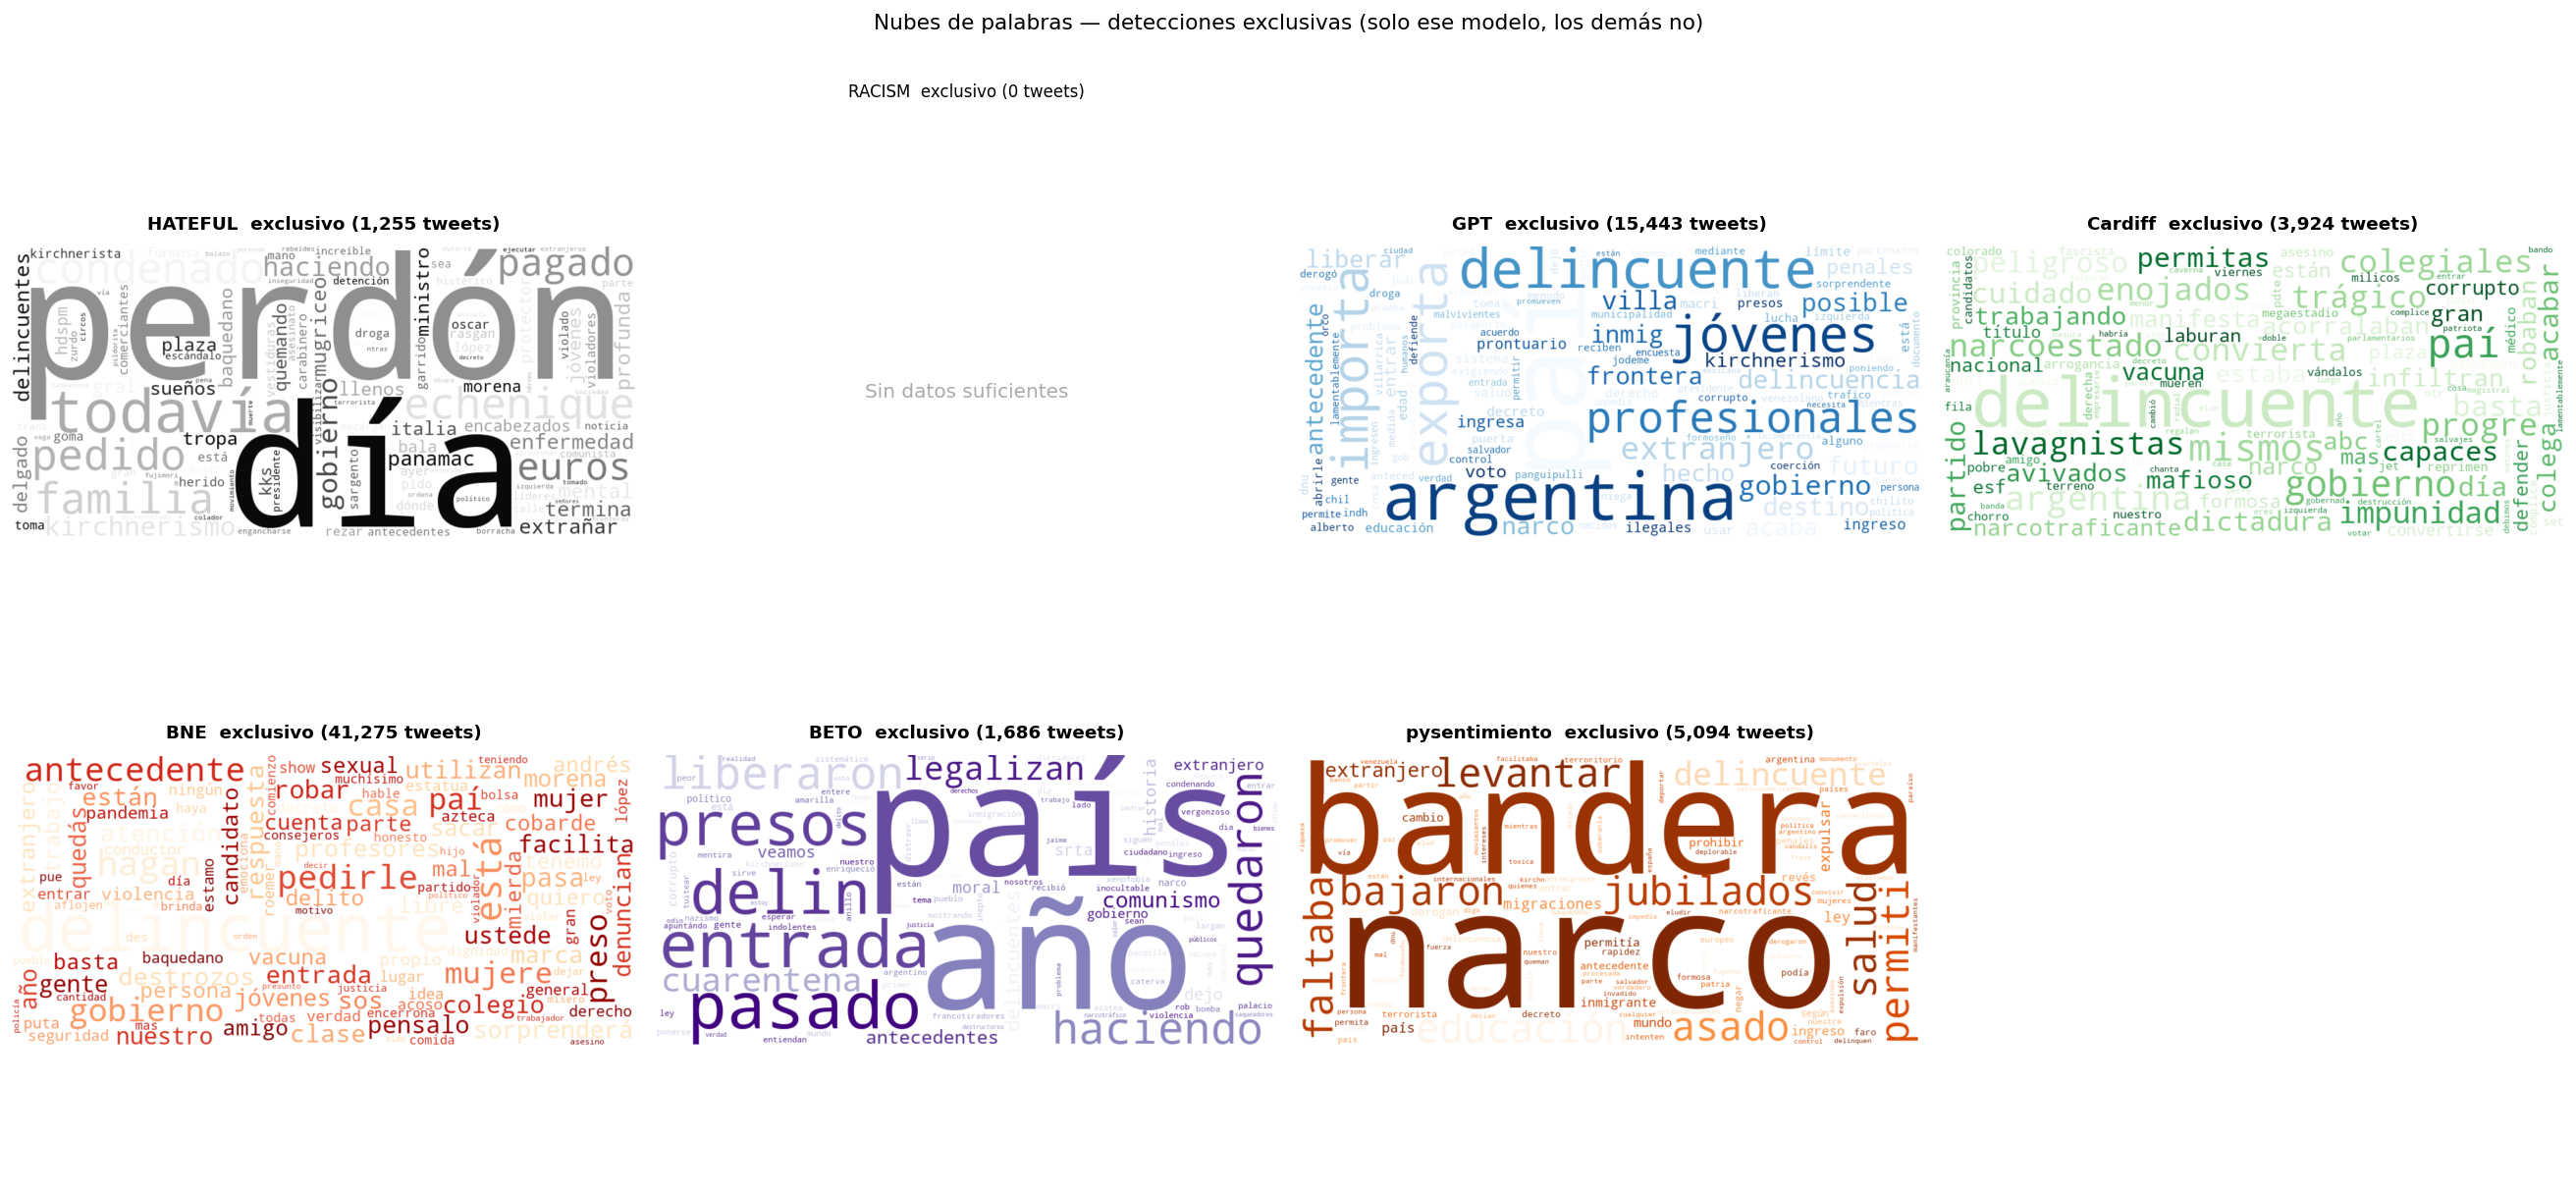

In [17]:
# ── Detecciones exclusivas: un solo clasificador marca como odio ──────────────
_CLASIF_FULL = CLASIF  # todos tienen cobertura completa
_hate_mat = df[_CLASIF_FULL].fillna(0).astype(int)

# Tabla resumen
rows_excl = []
for m in _CLASIF_FULL:
    otros = [x for x in _CLASIF_FULL if x != m]
    mask_excl = (df[m] == 1) & (_hate_mat[otros].sum(axis=1) == 0)
    n_excl = mask_excl.sum()
    n_hate = int((df[m] == 1).sum())
    rows_excl.append({
        'Clasificador': m,
        'Total odiosos': n_hate,
        'Detecciones exclusivas': n_excl,
        '% exclusivas': n_excl / n_hate * 100 if n_hate else 0,
    })

df_excl = pd.DataFrame(rows_excl).set_index('Clasificador')
display(
    df_excl.style
    .format({'Total odiosos': '{:,}', 'Detecciones exclusivas': '{:,}',
             '% exclusivas': '{:.1f}%'})
    .background_gradient(subset=['% exclusivas'], cmap='Oranges')
    .set_caption('Detecciones exclusivas — tweets marcados por SOLO ese modelo')
)

# ── Word clouds de detecciones exclusivas ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, m in enumerate(_CLASIF_FULL):
    otros = [x for x in _CLASIF_FULL if x != m]
    mask_excl = (df[m] == 1) & (_hate_mat[otros].sum(axis=1) == 0)
    n_excl = mask_excl.sum()
    corpus = ' '.join(df.loc[mask_excl, '_texto_limpio'])
    title  = f'{m}  exclusivo ({n_excl:,} tweets)'
    _make_wc(corpus, title, axes[i], CMAPS_WC[m])

axes[-1].axis('off')
fig.suptitle('Nubes de palabras — detecciones exclusivas (solo ese modelo, los demás no)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/wc_clasif_exclusivo.png', dpi=150, bbox_inches='tight')
plt.show()

### 13c. Frecuencia de palabras por clasificador

Top 30 palabras más frecuentes en los tweets odiosos de cada modelo (tabla) y top 20 como gráfico de barras horizontales. Reutiliza el mismo preprocesamiento que las nubes: sin URLs, menciones, hashtags ni stop words.

In [18]:
from collections import Counter

TOP_N_WORDS = 30
TOP_BAR     = 20

# ── Contar frecuencias (reutiliza _texto_limpio y _STOPWORDS_WC) ───────────────
freq_data = {}
for m in CLASIF:
    hate_mask = df[m] == 1
    corpus = ' '.join(df.loc[hate_mask, '_texto_limpio'])
    words  = [w for w in corpus.split() if w not in _STOPWORDS_WC and len(w) >= 3]
    freq_data[m] = Counter(words)
    n_hate = hate_mask.sum()
    print(f'{m:<15}  {n_hate:>7,} tweets odiosos  |  {len(freq_data[m]):,} palabras únicas')

# ── Tabla: top 30 por clasificador ────────────────────────────────────────────
rows = {}
for m in CLASIF:
    top = freq_data[m].most_common(TOP_N_WORDS)
    rows[m] = [f'{w}  ({n:,})' for w, n in top]
    while len(rows[m]) < TOP_N_WORDS:
        rows[m].append('')

freq_df = pd.DataFrame(rows, index=range(1, TOP_N_WORDS + 1))
freq_df.index.name = 'Rank'
display(
    freq_df.style
    .set_caption(f'Top {TOP_N_WORDS} palabras más frecuentes en tweets odiosos por clasificador')
    .set_table_styles([
        {'selector': 'th',  'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'td',  'props': [('font-size', '11px'), ('white-space', 'nowrap')]},
        {'selector': 'tr:nth-child(odd) td', 'props': [('background', '#f9f9f9')]},
    ])
)

HATEFUL           13,006 tweets odiosos  |  10,353 palabras únicas
RACISM             6,624 tweets odiosos  |  5,033 palabras únicas
GPT               42,554 tweets odiosos  |  12,448 palabras únicas
Cardiff           27,840 tweets odiosos  |  17,340 palabras únicas
BNE               74,295 tweets odiosos  |  29,636 palabras únicas
BETO              17,715 tweets odiosos  |  10,707 palabras únicas
pysentimiento     40,348 tweets odiosos  |  17,043 palabras únicas


,HATEFUL,RACISM,GPT,Cardiff,BNE,BETO,pysentimiento
Rank,,,,,,,
1,"extranjeros (5,244)","extranjeros (5,134)","delincuentes (24,699)","delincuentes (18,853)","delincuentes (45,107)","extranjeros (8,704)","delincuentes (20,444)"
2,"delincuentes (5,244)","delincuentes (1,930)","extranjeros (16,691)","extranjeros (3,554)","país (4,037)","antecedentes (6,051)","extranjeros (17,201)"
3,"familia (1,573)","argentina (1,275)","argentina (16,086)","país (2,477)","extranjeros (3,957)","delincuentes (5,751)","argentina (8,246)"
4,"país (1,416)","país (1,226)","país (14,245)","entrar (2,303)","antecedentes (3,842)","penales (5,547)","antecedentes (8,178)"
5,"argentina (1,326)","delinquen (1,204)","antecedentes (9,187)","gobierno (1,732)","gobierno (3,505)","ingreso (5,205)","ingreso (5,792)"
6,"delinquen (1,225)","manera (1,198)","jóvenes (8,725)","narcos (1,434)","mujeres (3,169)","argentina (5,158)","penales (5,494)"
7,"manera (1,207)","inmediata (1,197)","importa (8,393)","mierda (1,127)","entrar (2,877)","permitir (5,154)","permitir (5,355)"
8,"inmediata (1,204)","familia (1,192)","exporta (8,292)","delincuente (1,076)","mas (2,343)","facilitar (5,095)","facilitar (5,097)"
9,"junto (1,197)","junto (1,190)","profesionales (7,581)","argentino (1,042)","hagan (2,289)","narcotráfic (5,090)","narcotráfic (5,091)"


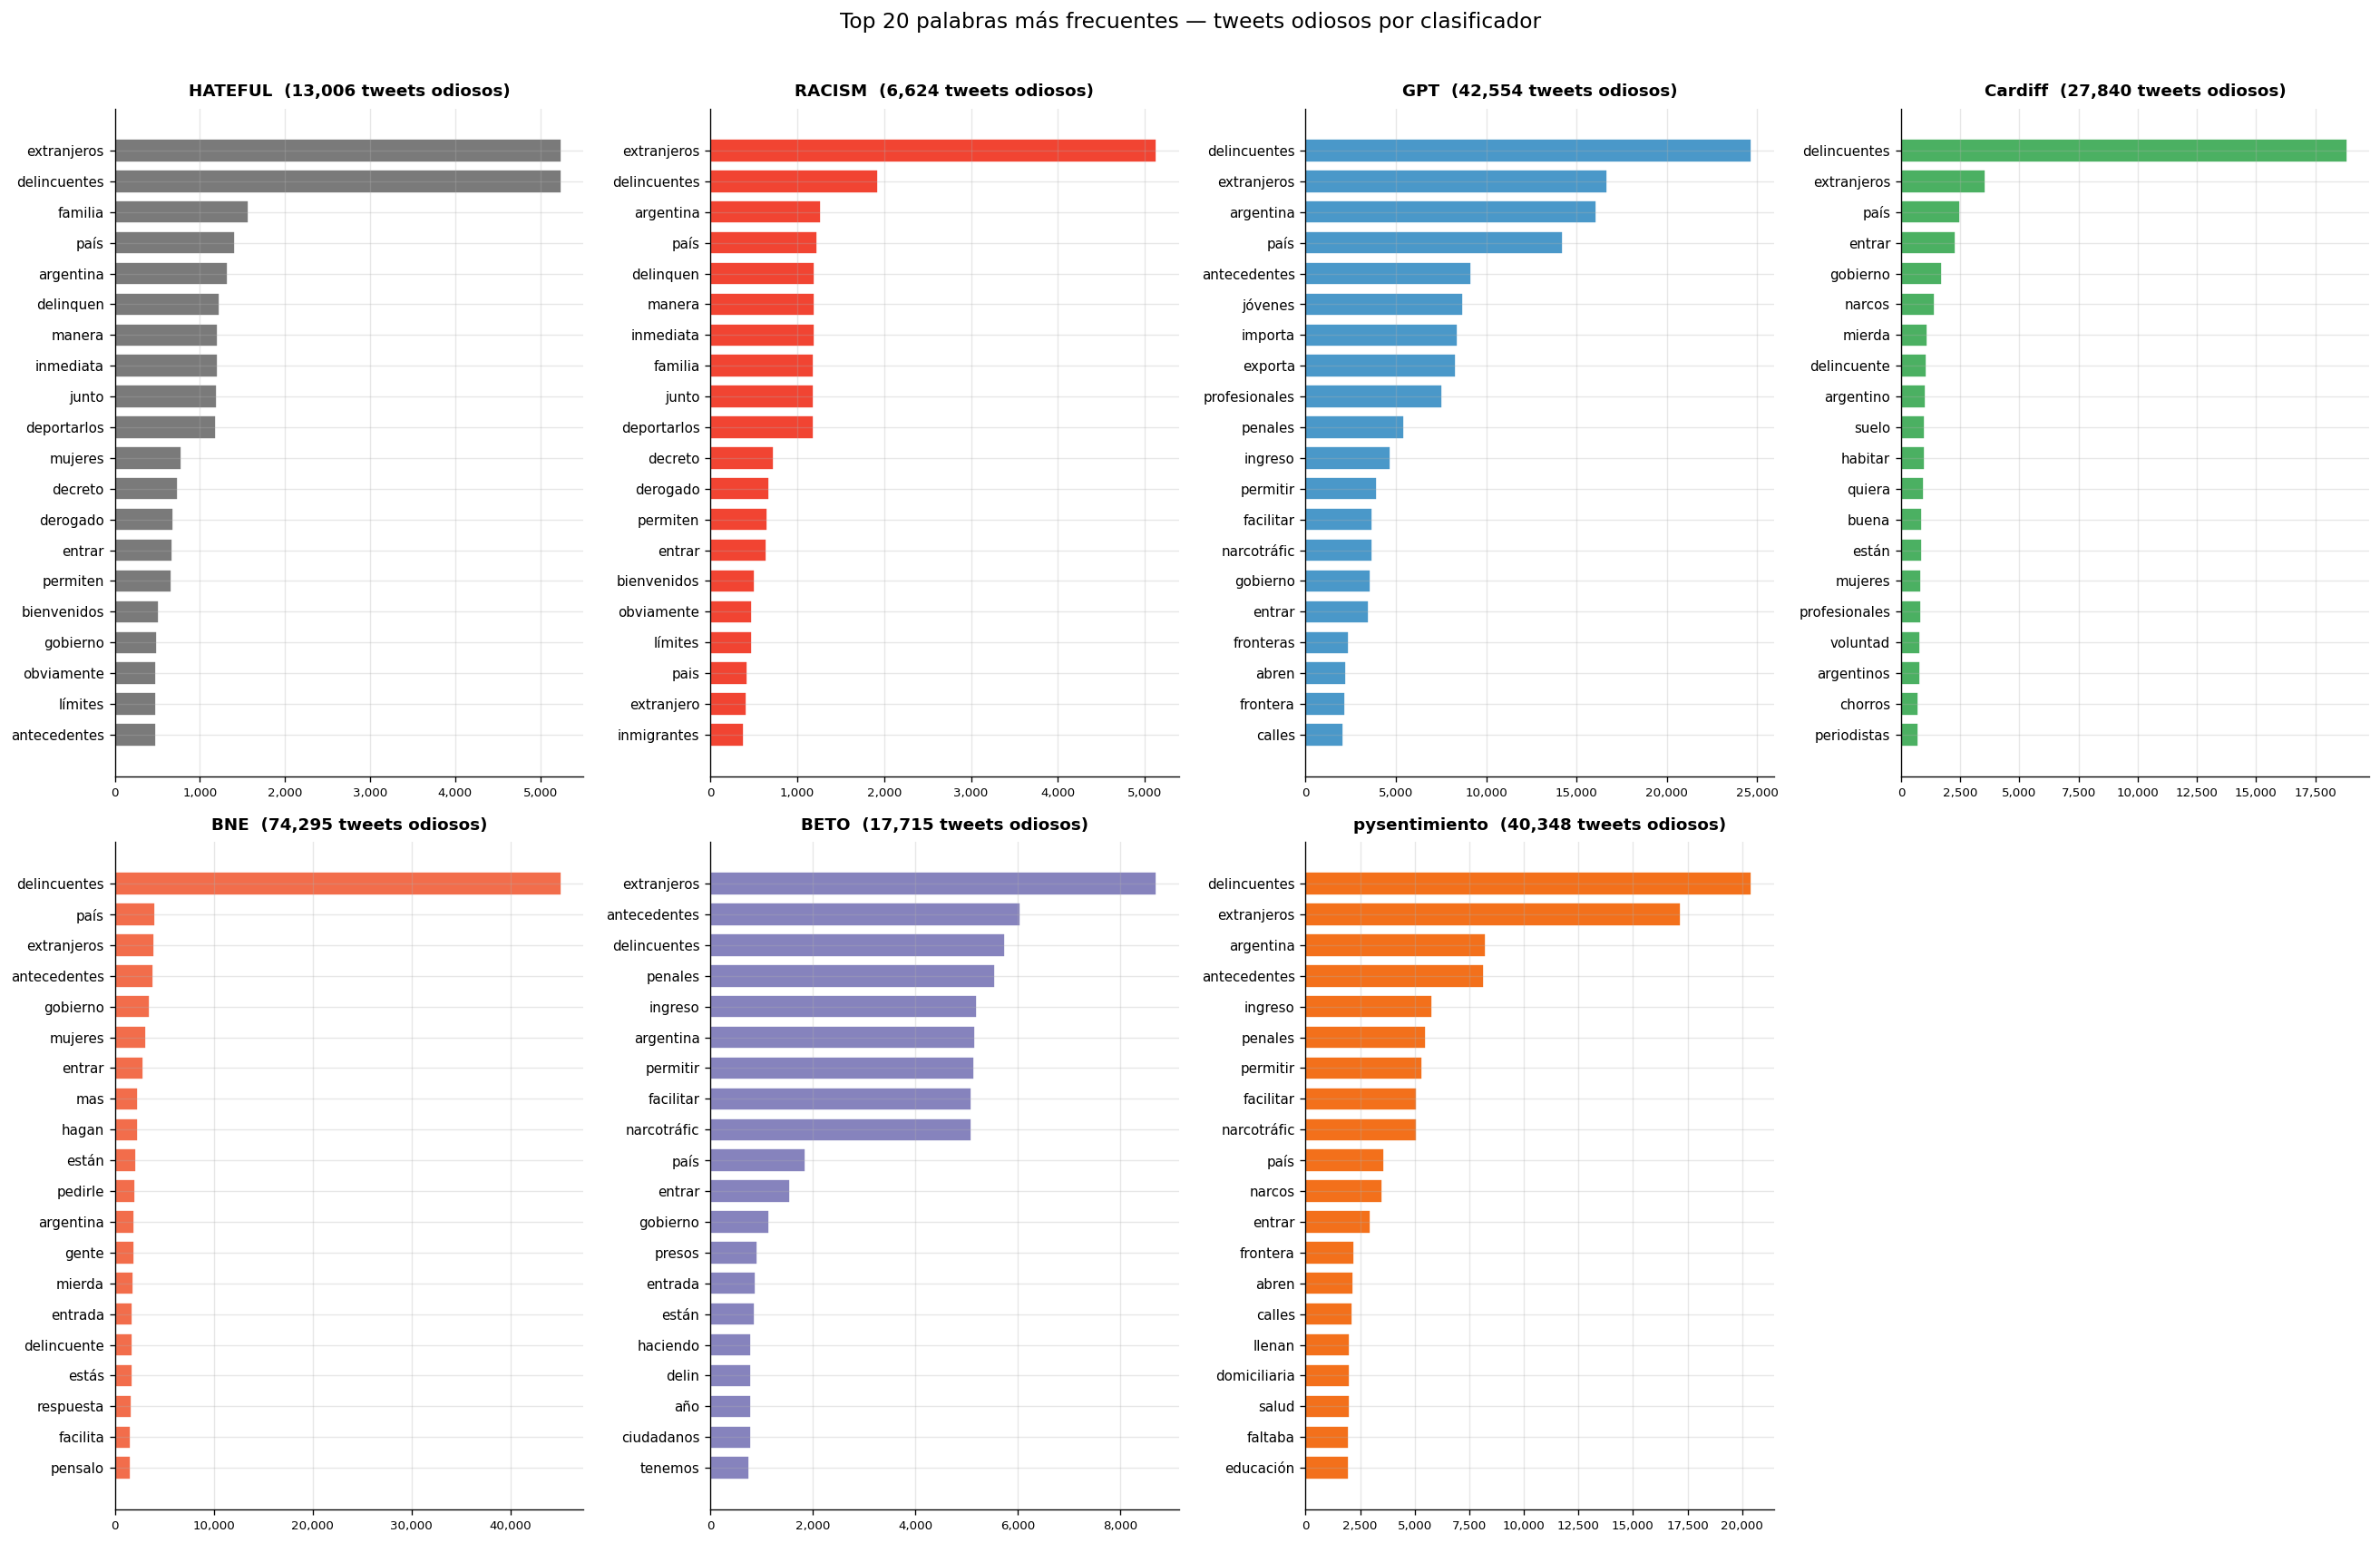

In [19]:
# ── Gráficos de barras horizontales: top 20 por clasificador ──────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 14))
axes = axes.flatten()

for i, m in enumerate(CLASIF):
    top = freq_data[m].most_common(TOP_BAR)
    if not top:
        axes[i].axis('off')
        continue
    words, counts = zip(*top)
    # Invertir: el más frecuente arriba
    y = list(range(len(words) - 1, -1, -1))
    cmap  = plt.get_cmap(CMAPS_WC[m])
    color = cmap(0.6)
    axes[i].barh(y, counts, color=color, edgecolor='white', height=0.75)
    axes[i].set_yticks(y)
    axes[i].set_yticklabels(words, fontsize=9)
    axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].tick_params(axis='x', labelsize=8)
    n_hate = int((df[m] == 1).sum())
    axes[i].set_title(f'{m}  ({n_hate:,} tweets odiosos)',
                      fontsize=11, fontweight='bold', pad=8)

axes[-1].axis('off')
fig.suptitle(f'Top {TOP_BAR} palabras más frecuentes — tweets odiosos por clasificador',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/wc_clasif_freq_barras.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import nbformat
from nbconvert import HTMLExporter
from datetime import date

nb_path  = '2_DNU_EDA_clasif.ipynb'
out_path = f'outputs/2_DNU_EDA_clasif_{date.today()}.html'

with open(nb_path, encoding='utf-8') as f:
    nb_node = nbformat.read(f, as_version=4)

body, _ = HTMLExporter().from_notebook_node(nb_node)

with open(out_path, 'w', encoding='utf-8') as f:
    f.write(body)

print(f'Guardado: {out_path} ({len(body)//1024} KB)')

Guardado: outputs/2_DNU_EDA_clasif_2026-04-08.html (4157 KB)
